# Season outputs loader
Helper cells to flexibly load season run outputs stored under `data/season_outputs/<run_id>`.
- Lists available runs
- Loads trip log, day summary, season person snapshots, SP day summary
- Discovers all `day_*_model_ts.parquet` files into a dict keyed by day index

Update `RUN_ID` below to point at the run you want to analyze.

In [171]:
import os
from pathlib import Path
import subprocess
import season.analysis_helpers as ah

# Get the top-level directory of the current git repo
PROJECT_ROOT = Path(
    subprocess.check_output(
        ["git", "rev-parse", "--show-toplevel"], text=True
    ).strip()
)

os.chdir(PROJECT_ROOT)


# Enable auto-reloading of custom modules
%load_ext autoreload
%autoreload 2

%pwd


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'/Users/zanderholleran/Desktop/python_projects/mesa_lcc_model'

In [172]:
ah.list_runs()

['example_season_001',
 'light_season_001',
 'speed_test',
 'speed_test2',
 'speed_test3',
 'speed_test4',
 'speed_test5',
 'speed_test6',
 'store_data_2days_test',
 'test',
 'test2k',
 'two_week_example_001',
 'volume_toll_1',
 'volume_toll_2',
 'volume_toll_3',
 'volume_toll_4',
 'volume_toll_5',
 'volume_toll_6']

## Load a run
Set `RUN_ID` to one of the `available_runs` above.

In [173]:
RUN_ID = 'speed_test6' 

run_data = ah.load_run(RUN_ID)
run_data_keys = {k: (list(v.keys()) if k == 'model_ts' else (None if v is None else getattr(v, 'shape', None))) for k, v in run_data.items()}
run_data_keys


{'run_dir': None,
 'trip_log': (9000, 9),
 'day_summary': (3, 17),
 'season_person_log': (9000, 18),
 'sp_day_summary': (3, 11),
 'model_ts': [0, 1, 2, 3, 4]}

## Quick peeks
Uncomment and run the snippets you need once a run is loaded.

In [174]:
print('='*20)
print('Model time series day 0')
print('Tier 1 data collected at 60s intervals')
print('='*20)
model_ts = run_data['model_ts']
display(model_ts[0].head()) if model_ts is not None and len(model_ts) > 0 else print('No model time series data')


Model time series day 0
Tier 1 data collected at 60s intervals


,step,p_generate,current_toll,vehicle_count,active_cars,bus_riders_waiting,active_buses,total_finished,bus_mode_share_recent,recent_travel_time_avg,rolling_count_vehicles_generated,rolling_count_persons_generated,implicit_sl_delta_bin_0,implicit_sl_delta_bin_1,implicit_sl_delta_bin_2,implicit_sl_delta_bin_3,implicit_sl_delta_bin_4
0,60,0.269111,0.0,8,8,0,0,0,0.0,NaN,0,0,0,0,0,1,7
1,120,0.268301,0.0,17,17,0,0,0,0.0,NaN,9,9,0,0,1,3,13
2,180,0.267490,0.0,34,34,0,0,0,0.0,NaN,26,26,0,0,1,9,24
3,240,0.266680,0.0,48,48,0,0,0,0.0,NaN,40,40,0,0,4,10,34
4,300,0.265870,0.0,63,63,0,0,0,0.0,NaN,55,55,0,1,0,26,36


In [179]:
print('='*100)
print('Day summary - one row per DAY, with aggregate metrics')
print('='*100)
day_summary = run_data['day_summary']
display(day_summary.head()) if day_summary is not None else print('No day summary data')  

print('='*100)
print('Trip log - one row per PERSON per DAY')
print('='*100)
trip_log = run_data['trip_log']
display(trip_log.head()) if trip_log is not None else print('No trip log data')  

print('='*100)
print('Season person log - one row per PERSON per DAY, with their mode and travel times')
print('='*100)
season_person_log = run_data['season_person_log']
display(season_person_log.loc[season_person_log.person_id == 1])



Day summary - one row per DAY, with aggregate metrics


,day_index,total_persons,share_bus,avg_wait_bus,avg_tt_bus,avg_tt_car,avg_toll_car,total_toll_car,avg_cumlost_bus,avg_cumlost_car,avg_tt,avg_cum_time_lost,avg_realized_cost,avg_realized_cost_vot_standardized,avg_onboard_time_bus,avg_realized_cost_bus,avg_realized_cost_car
0,0,3000,0.156333,24.388699,53.478785,28.434644,8.271948,20936.299981,8.708505,10.047603,32.349878,9.838258,32.482654,28.545352,29.090085,23.421718,23.421718
1,1,3000,0.145333,25.973968,54.502294,28.068812,7.503198,19238.200034,8.142603,9.725229,31.910478,9.495221,31.822486,27.686385,28.528326,26.830948,26.830948
2,2,3000,0.163667,65.302206,94.061677,28.615019,8.169271,20496.700006,8.375253,10.245567,39.326456,9.939459,36.220039,33.049870,28.759470,47.198269,47.198269


Trip log - one row per PERSON per DAY


,season_person_id,day_index,mode,toll_paid,realized_tt,wait_time,onboard_time,cumtime_lost_min,realized_cost
0,0,0,car,12.0,24.600000,0.000000,24.600000,8.569629,33.162656
1,1,0,car,4.2,26.183333,0.000000,26.183333,8.378783,16.375808
2,2,0,car,2.8,28.100000,0.000000,28.100000,9.620193,30.107430
3,3,0,car,10.5,29.200000,0.000000,29.200000,11.096210,30.498538
4,4,0,bus,0.0,54.416667,25.283333,29.133333,8.748378,16.505508


Season person log - one row per PERSON per DAY, with their mode and travel times


,day_index,person_id,season_id,value_of_time,expected_tt_car,expected_tt_bus,travel_time_uncertainty_car,travel_time_uncertainty_bus,prior_car,prior_bus,travel_propensity,experience_weight_car,experience_weight_bus,time_decay_rate,prior_weight,uncertainty_multiplier,history,realized_costs
1,0,1,speed_test6,0.465021,22.000000,40.0,1.000000,1.0,22.209167,40.000000,1.0,1.0,1.336663,0.1,1.0,1.0,"[{'cumtime_lost_min': 8.37878252215905, 'day_i...",[]
3001,1,1,speed_test6,0.465021,24.096979,40.0,0.551228,1.0,22.547875,40.000000,1.0,1.0,1.336663,0.1,1.0,1.0,"[{'cumtime_lost_min': 8.37878252215905, 'day_i...",[]
6001,2,1,speed_test6,0.465021,25.778749,40.0,0.385524,1.0,22.547875,43.809167,1.0,1.0,1.336663,0.1,1.0,1.0,"[{'cumtime_lost_min': 8.37878252215905, 'day_i...",[]


In [177]:
from season.analysis_helpers import plot_model_ts_interactive
plot_model_ts_interactive(model_ts, run_id=RUN_ID)


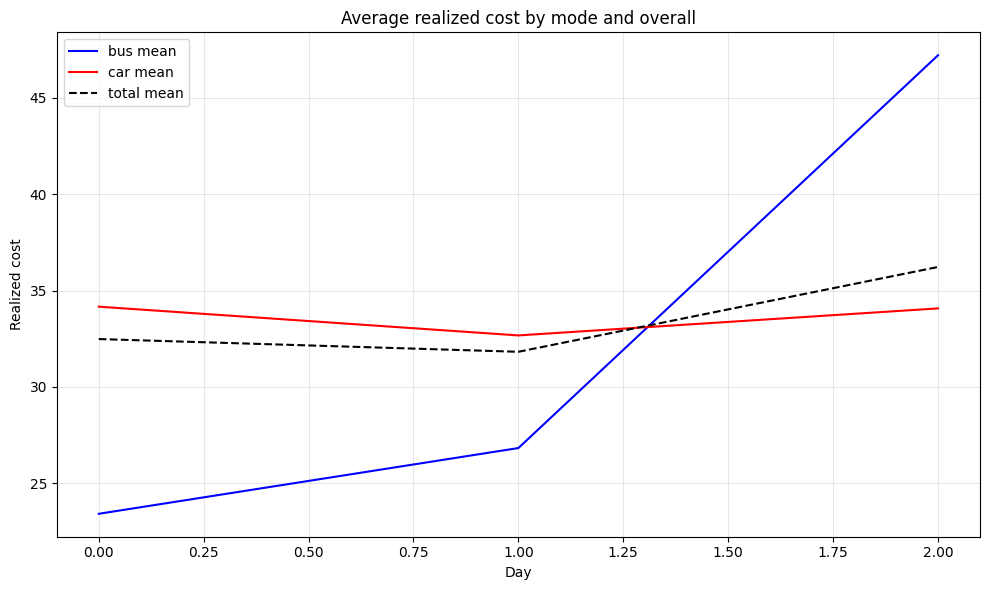

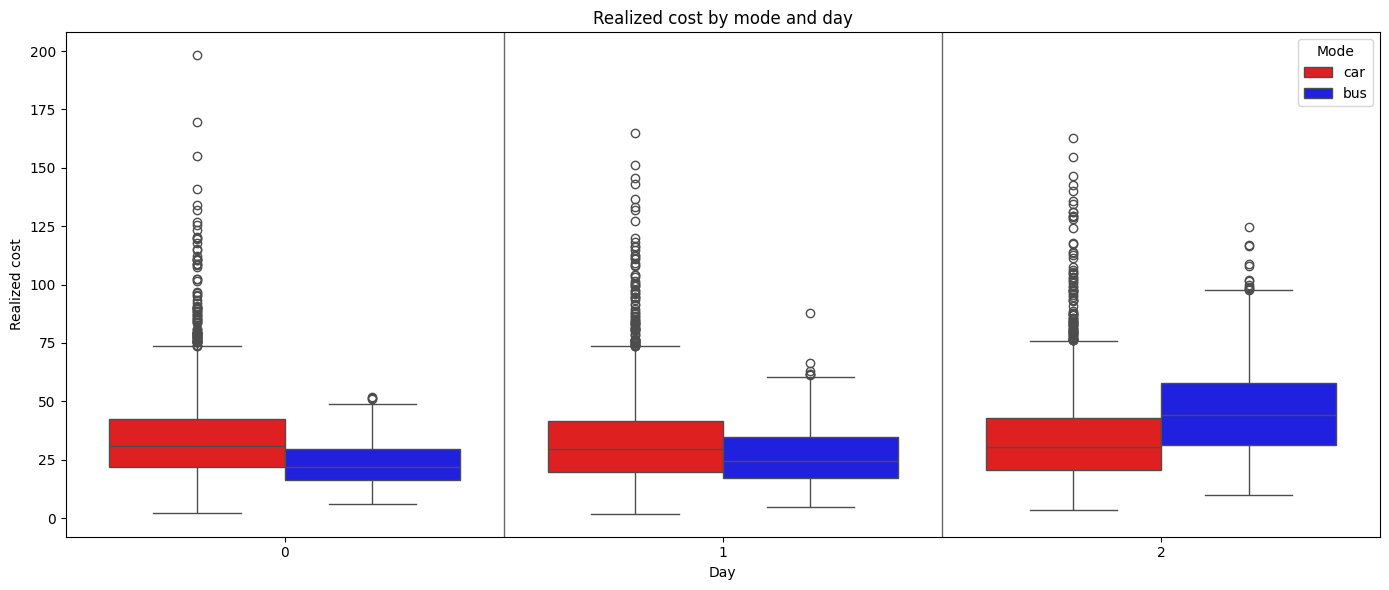

In [178]:
from season.analysis_helpers import plot_realized_cost_means_with_total
plot_realized_cost_means_with_total(trip_log)
from season.analysis_helpers import plot_realized_cost_boxplots
plot_realized_cost_boxplots(trip_log)
